In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df_main_resonance = pd.read_parquet("df_main_resonance.parquet")
df_holdout_resonance = pd.read_parquet("df_holdout_resonance.parquet")

In [3]:
def add_physics_features(df):
    df = df.copy()

    magic = np.array([2, 8, 20, 28, 50, 82, 126])

    # ratio / asymmetry features
    df["N_over_Z"] = df["N"] / df["Z"].replace(0, np.nan)
    df["A_over_Z"] = df["A"] / df["Z"].replace(0, np.nan)
    df["N_minus_Z"] = df["N"] - df["Z"]
    df["neutron_excess"] = (df["N"] - df["Z"]) / df["A"].replace(0, np.nan)

    # parity features
    df["Z_even"] = (df["Z"] % 2 == 0).astype(int)
    df["N_even"] = (df["N"] % 2 == 0).astype(int)
    df["A_even"] = (df["A"] % 2 == 0).astype(int)
    df["is_even_even"] = ((df["Z"] % 2 == 0) & (df["N"] % 2 == 0)).astype(int)
    df["is_odd_odd"] = ((df["Z"] % 2 == 1) & (df["N"] % 2 == 1)).astype(int)

    # shell / magic-number features
    df["dist_Z_magic"] = df["Z"].apply(lambda z: np.min(np.abs(magic - z)))
    df["dist_N_magic"] = df["N"].apply(lambda n: np.min(np.abs(magic - n)))
    df["Z_magic"] = df["Z"].isin(magic).astype(int)
    df["N_magic"] = df["N"].isin(magic).astype(int)

    # separation-energy combinations
    df["S_1n_minus_S_1p"] = df["S_1n_MeV"] - df["S_1p_MeV"]
    df["S_2n_minus_S_2p"] = df["S_2n_MeV"] - df["S_2p_MeV"]
    df["S_2n_minus_2S_1n"] = df["S_2n_MeV"] - 2 * df["S_1n_MeV"]
    df["S_2p_minus_2S_1p"] = df["S_2p_MeV"] - 2 * df["S_1p_MeV"]

    # energy features
    if "Energy" in df.columns:
        pos = df["Energy"] > 0
        df.loc[pos, "inv_sqrt_E"] = 1.0 / np.sqrt(df.loc[pos, "Energy"])
        df.loc[pos, "sqrt_E"] = np.sqrt(df.loc[pos, "Energy"])

    return df

Train rows: 2078262
Val rows  : 299762
Train groups: 995
Val groups  : 249
Shared groups: 0
MT in features? True

Linear-space metrics
RMSE: 523.685
MAE : 54.2962
R²  : 0.0274111

Log-space metrics
RMSE: 0.776311
MAE : 0.541441
R²  : 0.63104


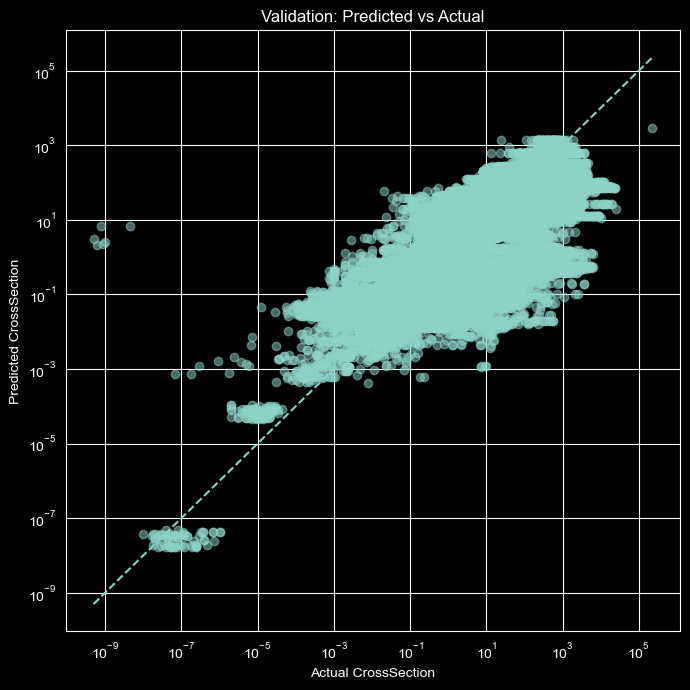

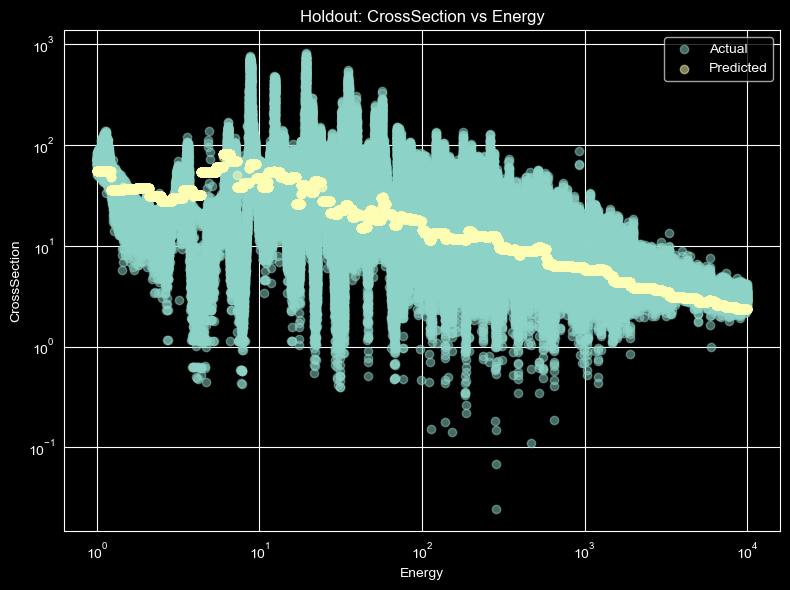


Top 20 feature importances:
Z_even                0.233655
N_even                0.205473
S_2n_MeV              0.130113
Z                     0.093178
MT                    0.046591
out_f                 0.043345
out_g                 0.042344
out_a                 0.028641
dist_Z_magic          0.023200
S_1n_MeV              0.019121
S_2p_minus_2S_1p      0.018698
S_2n_minus_2S_1n      0.010565
is_odd_odd            0.009782
dist_N_magic          0.009263
N_over_Z              0.008900
S_2n_minus_S_2p       0.008446
is_even_even          0.007661
S_1n_minus_S_1p       0.007656
A_over_Z              0.007005
Binding_Energy_MeV    0.006744
dtype: float32


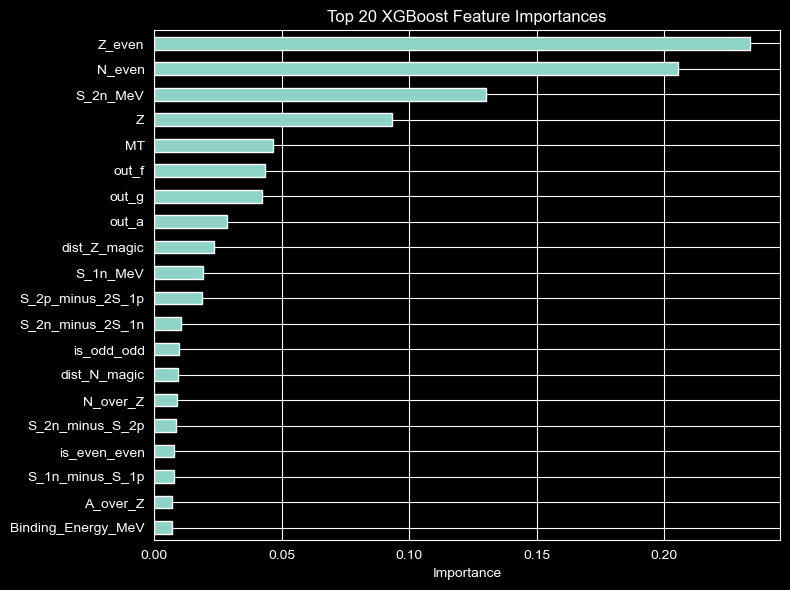

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from xgboost import XGBRegressor
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# --------------------------------------------------
# 1. Copy data
# --------------------------------------------------
df_train = df_main_resonance.copy()
df_holdout = df_holdout_resonance.copy()

df_train = add_physics_features(df_train)
df_holdout = add_physics_features(df_holdout)
# --------------------------------------------------
# 2. Keep only rows valid for log transforms
# --------------------------------------------------
df_train = df_train[(df_train["CrossSection"] > 0) & (df_train["Energy"] > 0)].copy()
df_holdout = df_holdout[df_holdout["Energy"] > 0].copy()

# --------------------------------------------------
# 3. Add log features / target
# --------------------------------------------------
df_train["log_CrossSection"] = np.log10(df_train["CrossSection"])
df_train["log_Energy"] = np.log10(df_train["Energy"])
df_holdout["log_Energy"] = np.log10(df_holdout["Energy"])

# --------------------------------------------------
# 4. Build grouping column using Z, A, MT
#    This is for splitting only
# --------------------------------------------------
group_cols = ["Z", "A", "MT"]
missing_group_cols = [c for c in group_cols if c not in df_train.columns]
if missing_group_cols:
    raise ValueError(f"Missing grouping columns in df_main_thermal: {missing_group_cols}")

df_train["group_key"] = (
        df_train["Z"].astype(str) + "_" +
        df_train["A"].astype(str) + "_" +
        df_train["MT"].astype(str)
)

groups = df_train["group_key"]

# --------------------------------------------------
# 5. Define features and target
#    MT is now INCLUDED in training
# --------------------------------------------------
target_col = "log_CrossSection"

cols_to_remove = [
    "Entry",
    "CrossSection",
    "Uncertainty",
    "log_CrossSection",
    "group_key"
]

X = df_train.drop(columns=cols_to_remove, errors="ignore").copy()
y = df_train[target_col].copy()

X_holdout = df_holdout.drop(
    columns=["Entry", "CrossSection", "Uncertainty"],
    errors="ignore"
).copy()

# --------------------------------------------------
# 6. One-hot encode categoricals if needed
# --------------------------------------------------
X = pd.get_dummies(X, drop_first=False)
X_holdout = pd.get_dummies(X_holdout, drop_first=False)

# Align holdout columns to training columns
X_holdout = X_holdout.reindex(columns=X.columns, fill_value=0)

# --------------------------------------------------
# 7. Group-based train/validation split
# --------------------------------------------------
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, val_idx = next(gss.split(X, y, groups=groups))

X_train = X.iloc[train_idx]
X_val = X.iloc[val_idx]
y_train = y.iloc[train_idx]
y_val = y.iloc[val_idx]

train_groups = groups.iloc[train_idx]
val_groups = groups.iloc[val_idx]

print(f"Train rows: {len(X_train)}")
print(f"Val rows  : {len(X_val)}")
print(f"Train groups: {train_groups.nunique()}")
print(f"Val groups  : {val_groups.nunique()}")
print(f"Shared groups: {len(set(train_groups).intersection(set(val_groups)))}")
print("MT in features?", "MT" in X.columns)

# --------------------------------------------------
# 8. Train model
# --------------------------------------------------
model = XGBRegressor(
    n_estimators=1000,
    max_depth=6,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train,
    y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=False
)

# --------------------------------------------------
# 9. Validation predictions
# --------------------------------------------------
y_val_pred_log = model.predict(X_val)

y_val_true = 10 ** y_val
y_val_pred = 10 ** y_val_pred_log

print("\nLinear-space metrics")
print(f"RMSE: {mean_squared_error(y_val_true, y_val_pred) ** 0.5:.6g}")
print(f"MAE : {mean_absolute_error(y_val_true, y_val_pred):.6g}")
print(f"R²  : {r2_score(y_val_true, y_val_pred):.6g}")

print("\nLog-space metrics")
print(f"RMSE: {mean_squared_error(y_val, y_val_pred_log) ** 0.5:.6g}")
print(f"MAE : {mean_absolute_error(y_val, y_val_pred_log):.6g}")
print(f"R²  : {r2_score(y_val, y_val_pred_log):.6g}")

# --------------------------------------------------
# 10. Predict on holdout
# --------------------------------------------------
holdout_pred_log = model.predict(X_holdout)
holdout_pred = 10 ** holdout_pred_log

df_holdout_pred = df_holdout.copy()
df_holdout_pred["Predicted_log_CrossSection"] = holdout_pred_log
df_holdout_pred["Predicted_CrossSection"] = holdout_pred

# --------------------------------------------------
# 11. Plot: validation predicted vs actual
# --------------------------------------------------
plt.figure(figsize=(7, 7))
plt.scatter(y_val_true, y_val_pred, alpha=0.5)

min_val = min(y_val_true.min(), y_val_pred.min())
max_val = max(y_val_true.max(), y_val_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.xscale("log")
plt.yscale("log")
plt.xlabel("Actual CrossSection")
plt.ylabel("Predicted CrossSection")
plt.title("Validation: Predicted vs Actual")
plt.tight_layout()
plt.show()

# --------------------------------------------------
# 12. Plot: holdout cross section vs energy
# --------------------------------------------------
plt.figure(figsize=(8, 6))

if "CrossSection" in df_holdout_pred.columns:
    mask_actual = df_holdout_pred["CrossSection"] > 0
    plt.scatter(
        df_holdout_pred.loc[mask_actual, "Energy"],
        df_holdout_pred.loc[mask_actual, "CrossSection"],
        alpha=0.5,
        label="Actual"
    )

plt.scatter(
    df_holdout_pred["Energy"],
    df_holdout_pred["Predicted_CrossSection"],
    alpha=0.5,
    label="Predicted"
)

plt.xscale("log")
plt.yscale("log")
plt.xlabel("Energy")
plt.ylabel("CrossSection")
plt.title("Holdout: CrossSection vs Energy")
plt.legend()
plt.tight_layout()
plt.show()

# --------------------------------------------------
# 13. Feature importance
# --------------------------------------------------
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)

print("\nTop 20 feature importances:")
print(importances.head(20))

plt.figure(figsize=(8, 6))
importances.head(20).sort_values().plot(kind="barh")
plt.xlabel("Importance")
plt.title("Top 20 XGBoost Feature Importances")
plt.tight_layout()
plt.show()

Using device: mps
Train rows: 2078262
Val rows  : 299762
Train groups: 995
Val groups  : 249
Shared groups: 0
MT in features? True
Epoch   0 | Train Loss: 0.324786 | Val Loss: 0.594047
Epoch  10 | Train Loss: 0.250704 | Val Loss: 0.581376
Epoch  20 | Train Loss: 0.244679 | Val Loss: 0.591179
Epoch  30 | Train Loss: 0.241999 | Val Loss: 0.596504
Early stopping at epoch 36

Linear-space metrics
RMSE: 528.07
MAE : 57.496
R²  : 0.0110558

Log-space metrics
RMSE: 0.84843
MAE : 0.600084
R²  : 0.559304


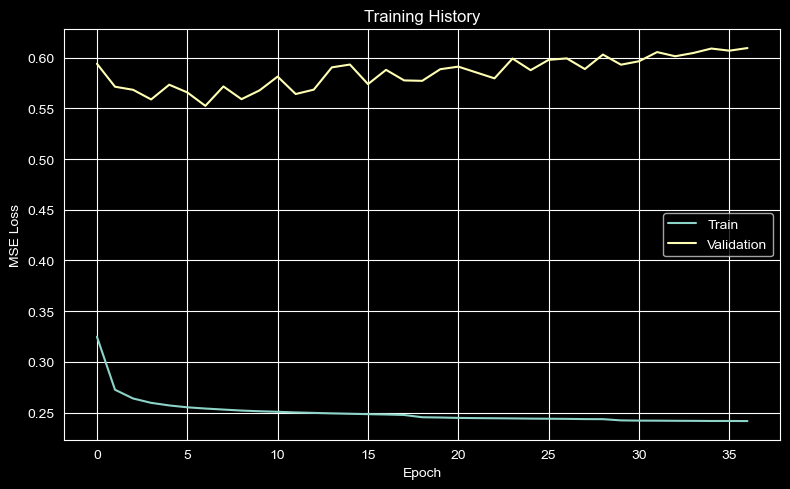

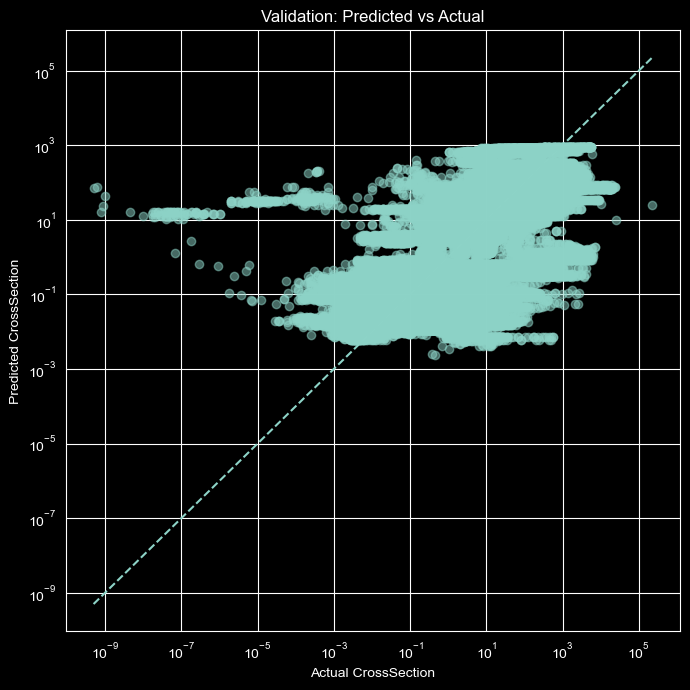

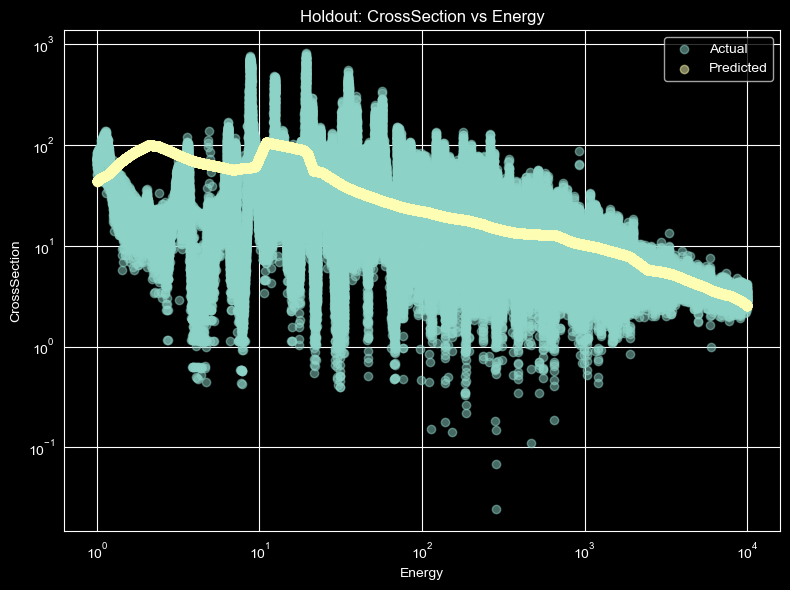

In [5]:
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

# --------------------------------------------------
# 0. Device
# --------------------------------------------------
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("Using device:", device)

# --------------------------------------------------
# 1. Copy data
# --------------------------------------------------
df_train = df_main_resonance.copy()
df_holdout = df_holdout_resonance.copy()

df_train = add_physics_features(df_train)
df_holdout = add_physics_features(df_holdout)

# Optional cleanup for engineered features
df_train = df_train.replace([np.inf, -np.inf], np.nan)
df_holdout = df_holdout.replace([np.inf, -np.inf], np.nan)

# --------------------------------------------------
# 2. Keep only rows valid for log transforms
# --------------------------------------------------
df_train = df_train[
    (df_train["CrossSection"] > 0) &
    (df_train["Energy"] > 0)
    ].copy()

df_holdout = df_holdout[df_holdout["Energy"] > 0].copy()

# --------------------------------------------------
# 3. Add log features / target
# --------------------------------------------------
df_train["log_CrossSection"] = np.log10(df_train["CrossSection"])
df_train["log_Energy"] = np.log10(df_train["Energy"])
df_holdout["log_Energy"] = np.log10(df_holdout["Energy"])

# --------------------------------------------------
# 4. Build grouping column using Z, A, MT
# --------------------------------------------------
group_cols = ["Z", "A", "MT"]
missing_group_cols = [c for c in group_cols if c not in df_train.columns]
if missing_group_cols:
    raise ValueError(f"Missing grouping columns in df_main_thermal: {missing_group_cols}")

df_train["group_key"] = (
        df_train["Z"].astype(str) + "_" +
        df_train["A"].astype(str) + "_" +
        df_train["MT"].astype(str)
)

groups = df_train["group_key"]

# --------------------------------------------------
# 5. Define features and target
# --------------------------------------------------
target_col = "log_CrossSection"

cols_to_remove = [
    "Entry",
    "CrossSection",
    "Uncertainty",
    "log_CrossSection",
    "group_key"
]

X = df_train.drop(columns=cols_to_remove, errors="ignore").copy()
y = df_train[target_col].copy()

X_holdout = df_holdout.drop(
    columns=["Entry", "CrossSection", "Uncertainty"],
    errors="ignore"
).copy()

# --------------------------------------------------
# 6. One-hot encode categoricals if needed
# --------------------------------------------------
X = pd.get_dummies(X, drop_first=False)
X_holdout = pd.get_dummies(X_holdout, drop_first=False)

# Align holdout columns to training columns
X_holdout = X_holdout.reindex(columns=X.columns, fill_value=0)

# --------------------------------------------------
# 7. Group-based train/validation split
# --------------------------------------------------
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, val_idx = next(gss.split(X, y, groups=groups))

X_train = X.iloc[train_idx].copy()
X_val = X.iloc[val_idx].copy()
y_train = y.iloc[train_idx].copy()
y_val = y.iloc[val_idx].copy()

train_groups = groups.iloc[train_idx]
val_groups = groups.iloc[val_idx]

print(f"Train rows: {len(X_train)}")
print(f"Val rows  : {len(X_val)}")
print(f"Train groups: {train_groups.nunique()}")
print(f"Val groups  : {val_groups.nunique()}")
print(f"Shared groups: {len(set(train_groups).intersection(set(val_groups)))}")
print("MT in features?", "MT" in X.columns)

# --------------------------------------------------
# 8. Handle missing values + scale features
#    Neural nets need this much more than XGBoost
# --------------------------------------------------
# Fill training NaNs with training medians, then apply same medians to val/holdout
train_medians = X_train.median(numeric_only=True)
X_train = X_train.fillna(train_medians)
X_val = X_val.fillna(train_medians)
X_holdout = X_holdout.fillna(train_medians)

# Standardize inputs
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_holdout_scaled = scaler.transform(X_holdout)

# Targets as float32 arrays
y_train_np = y_train.to_numpy(dtype=np.float32).reshape(-1, 1)
y_val_np = y_val.to_numpy(dtype=np.float32).reshape(-1, 1)

# --------------------------------------------------
# 9. Convert to tensors / dataloaders
# --------------------------------------------------
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
X_holdout_tensor = torch.tensor(X_holdout_scaled, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train_np, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val_np, dtype=torch.float32)

batch_size = 1024

train_ds = TensorDataset(X_train_tensor, y_train_tensor)
val_ds = TensorDataset(X_val_tensor, y_val_tensor)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)


# --------------------------------------------------
# 10. Define neural net
# --------------------------------------------------
class CrossSectionNet(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.10),

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.10),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.net(x)


model = CrossSectionNet(input_dim=X_train.shape[1]).to(device)

# --------------------------------------------------
# 11. Loss, optimizer
# --------------------------------------------------
criterion = nn.SmoothL1Loss(beta=0.1)
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-3
)

# Optional learning-rate scheduler
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=10
)

# --------------------------------------------------
# 12. Training loop with early stopping
# --------------------------------------------------
num_epochs = 300
patience = 30

best_val_loss = float("inf")
best_state = copy.deepcopy(model.state_dict())
epochs_no_improve = 0

train_losses = []
val_losses = []

for epoch in range(num_epochs):
    # ---- train ----
    model.train()
    running_train_loss = 0.0
    n_train = 0

    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()
        preds = model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item() * xb.size(0)
        n_train += xb.size(0)

    epoch_train_loss = running_train_loss / n_train

    # ---- validate ----
    model.eval()
    running_val_loss = 0.0
    n_val = 0

    with torch.no_grad():
        for xb, yb in val_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            preds = model(xb)
            loss = criterion(preds, yb)

            running_val_loss += loss.item() * xb.size(0)
            n_val += xb.size(0)

    epoch_val_loss = running_val_loss / n_val

    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)

    scheduler.step(epoch_val_loss)

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        best_state = copy.deepcopy(model.state_dict())
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1

    if epoch % 10 == 0 or epoch == num_epochs - 1:
        print(
            f"Epoch {epoch:3d} | "
            f"Train Loss: {epoch_train_loss:.6f} | "
            f"Val Loss: {epoch_val_loss:.6f}"
        )

    if epochs_no_improve >= patience:
        print(f"Early stopping at epoch {epoch}")
        break

# Load best model
model.load_state_dict(best_state)

# --------------------------------------------------
# 13. Validation predictions
# --------------------------------------------------
model.eval()
with torch.no_grad():
    y_val_pred_log = model(X_val_tensor.to(device)).cpu().numpy().ravel()

y_val_true = 10 ** y_val.to_numpy()
y_val_pred = 10 ** y_val_pred_log

print("\nLinear-space metrics")
print(f"RMSE: {mean_squared_error(y_val_true, y_val_pred) ** 0.5:.6g}")
print(f"MAE : {mean_absolute_error(y_val_true, y_val_pred):.6g}")
print(f"R²  : {r2_score(y_val_true, y_val_pred):.6g}")

print("\nLog-space metrics")
print(f"RMSE: {mean_squared_error(y_val, y_val_pred_log) ** 0.5:.6g}")
print(f"MAE : {mean_absolute_error(y_val, y_val_pred_log):.6g}")
print(f"R²  : {r2_score(y_val, y_val_pred_log):.6g}")

# --------------------------------------------------
# 14. Predict on holdout
# --------------------------------------------------
model.eval()
with torch.no_grad():
    holdout_pred_log = model(X_holdout_tensor.to(device)).cpu().numpy().ravel()

holdout_pred = 10 ** holdout_pred_log

df_holdout_pred = df_holdout.copy()
df_holdout_pred["Predicted_log_CrossSection"] = holdout_pred_log
df_holdout_pred["Predicted_CrossSection"] = holdout_pred

# --------------------------------------------------
# 15. Plot: training history
# --------------------------------------------------
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Train")
plt.plot(val_losses, label="Validation")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training History")
plt.legend()
plt.tight_layout()
plt.show()

# --------------------------------------------------
# 16. Plot: validation predicted vs actual
# --------------------------------------------------
plt.figure(figsize=(7, 7))
plt.scatter(y_val_true, y_val_pred, alpha=0.5)

min_val = min(y_val_true.min(), y_val_pred.min())
max_val = max(y_val_true.max(), y_val_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.xscale("log")
plt.yscale("log")
plt.xlabel("Actual CrossSection")
plt.ylabel("Predicted CrossSection")
plt.title("Validation: Predicted vs Actual")
plt.tight_layout()
plt.show()

# --------------------------------------------------
# 17. Plot: holdout cross section vs energy
# --------------------------------------------------
plt.figure(figsize=(8, 6))

if "CrossSection" in df_holdout_pred.columns:
    mask_actual = df_holdout_pred["CrossSection"] > 0
    plt.scatter(
        df_holdout_pred.loc[mask_actual, "Energy"],
        df_holdout_pred.loc[mask_actual, "CrossSection"],
        alpha=0.5,
        label="Actual"
    )

plt.scatter(
    df_holdout_pred["Energy"],
    df_holdout_pred["Predicted_CrossSection"],
    alpha=0.5,
    label="Predicted"
)

plt.xscale("log")
plt.yscale("log")
plt.xlabel("Energy")
plt.ylabel("CrossSection")
plt.title("Holdout: CrossSection vs Energy")
plt.legend()
plt.tight_layout()
plt.show()